<a href="https://colab.research.google.com/github/jcdumlao14/ESSPOCO19-DataAnalysis/blob/main/Spatial_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This analysis examines how social class (Socio-Economic Status) and geographic location influenced the levels of hardship people experienced during the COVID-19 pandemic across Europe.

1. **Data Sourcing and Cleaning:** The study utilizes the European Social Survey (ESS), mapping respondents into four regions: **North, West, South, and East.** To ensure accuracy, responses were filtered to remove invalid entries, keeping only those with valid age, education, and income data.
2. **Creating the "Hardship" and "SES" Scores:**
 - **SES (Social Class) Index:** This was calculated by averaging the standardized scores (Z-scores) of a person’s years of education and their household income.
 - **COVID Hardship Index:** This combined measure tracked psychological distress, financial struggle, and life satisfaction. A positive score (e.g., **0.15**) indicates higher-than-average hardship, while a negative score (e.g., **-0.12**) indicates lower-than-average distress.
3. **Grouping:** Participants were divided into three tiers based on their SES Index. The **Low SES group** had a mean age of **49**, while the High SES group was slightly younger with a mean age of **44**.

# **Import Libraries**
- **Import necessary tools:** The code starts by bringing in several Python libraries that provide functions for data manipulation, visualization, machine learning, and handling imbalanced datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from scipy.stats import zscore
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings("ignore")

# **Global Visual Style**

In [2]:
# --- Global Styling ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'sans-serif'],
    'figure.facecolor': 'white',
    'axes.edgecolor': '#333333'
})

# **Load Data**

In [3]:
# 1. LOAD DATA
zip_path = '/content/ESS11e04_1.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('ESS11e04_1.csv') as f:
        df_raw = pd.read_csv(f, low_memory=False)

df = df_raw.copy()
print("--- Data Loading Result ---")
print("Dataset Loaded. Shape:", df.shape)

--- Data Loading Result ---
Dataset Loaded. Shape: (50116, 691)


# **Mapping & Cleaning**

In [4]:
# MAPPING & CLEANING
region_map = {
    # North
    'NO': 'North', 'SE': 'North', 'DK': 'North', 'FI': 'North', 'IS': 'North', 'GB': 'North', 'IE': 'North',
    # West
    'FR': 'West', 'BE': 'West', 'NL': 'West', 'LU': 'West', 'DE': 'West', 'AT': 'West', 'CH': 'West',
    # South
    'ES': 'South', 'PT': 'South', 'IT': 'South', 'GR': 'South', 'CY': 'South', 'MT': 'South', 'IL': 'South',
    # East
    'PL': 'East', 'CZ': 'East', 'SK': 'East', 'HU': 'East', 'RO': 'East', 'BG': 'East', 'SI': 'East',
    'HR': 'East', 'UA': 'East', 'ME': 'East', 'LV': 'East', 'LT': 'East', 'RS': 'East', 'EE': 'East', 'CU': 'East'
}

country_names = {
    'NO': 'Norway', 'SE': 'Sweden', 'DK': 'Denmark', 'FI': 'Finland', 'IS': 'Iceland',
    'GB': 'United Kingdom', 'IE': 'Ireland', 'FR': 'France', 'BE': 'Belgium', 'NL': 'Netherlands',
    'LU': 'Luxembourg', 'DE': 'Germany', 'AT': 'Austria', 'CH': 'Switzerland',
    'ES': 'Spain', 'PT': 'Portugal', 'IT': 'Italy', 'GR': 'Greece', 'CY': 'Cyprus', 'MT': 'Malta',
    'IL': 'Israel', 'PL': 'Poland', 'CZ': 'Czech Republic', 'SK': 'Slovakia', 'HU': 'Hungary',
    'RO': 'Romania', 'BG': 'Bulgaria', 'SI': 'Slovenia', 'HR': 'Croatia', 'UA': 'Ukraine',
    'ME': 'Montenegro', 'LV': 'Latvia', 'LT': 'Lithuania', 'RS': 'Serbia', 'EE': 'Estonia', 'CU': 'Other (CU)'
}

df['region'] = df['cntry'].map(region_map).fillna('Unknown')
df['country_name'] = df['cntry'].map(country_names).fillna(df['cntry'])

cols_to_clean = ['eduyrs', 'hinctnta', 'fltdpr', 'hincfel', 'stflife', 'agea']
for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df[df[col] < 70] # Filter valid ESS responses (removes 77, 88, 99)

# Index Construction
df['SES_Index'] = df[['eduyrs', 'hinctnta']].apply(zscore, nan_policy='omit').mean(axis=1)
df['COVID_Hardship'] = df[['fltdpr', 'hincfel', 'stflife']].apply(zscore, nan_policy='omit').mean(axis=1)
df['SES_Group'] = pd.qcut(df['SES_Index'], 3, labels=['Low SES', 'Middle SES', 'High SES'])


# **Statistical Summary**

In [5]:
# STATISTICAL SUMMARY
print("\n--- Summary Statistics (Means by SES Group) ---")
summary_stats = df.groupby('SES_Group')[['COVID_Hardship', 'agea', 'stflife']].mean().round(3)
print(summary_stats)



--- Summary Statistics (Means by SES Group) ---
            COVID_Hardship    agea  stflife
SES_Group                                  
Low SES              0.153  48.977    6.453
Middle SES          -0.030  44.987    7.089
High SES            -0.128  44.473    7.662


# **Distribution by SES & Region**

There is a stark **"Social Gradient"** in the data. The **Low SES group** reported a hardship mean of **0.153**, while the **High SES group** reported a much lower **-0.128**. Geographically, the **East** region stands out as the most distressed area (appearing highest on the point plot), while the **North** reported the most resilient scores.

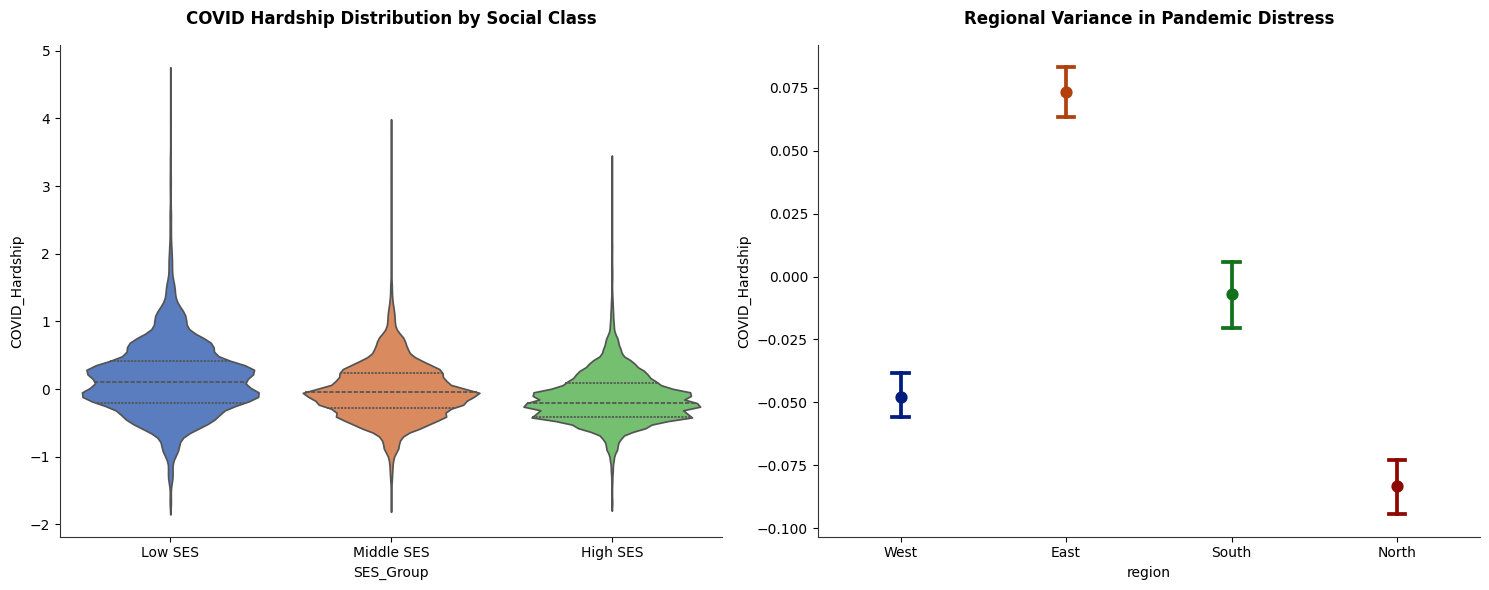

In [6]:
# CORE VISUALIZATIONS
# Plot A: Distribution by SES & Region
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.violinplot(x='SES_Group', y='COVID_Hardship', data=df, palette='muted', inner='quartile', ax=ax[0])
ax[0].set_title('COVID Hardship Distribution by Social Class', pad=15, weight='bold')
sns.pointplot(x='region', y='COVID_Hardship', data=df, join=False, palette='dark', capsize=.1, ax=ax[1])
ax[1].set_title('Regional Variance in Pandemic Distress', pad=15, weight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('SES_Regional_Hardship.png')
plt.show()


# **Correlation Analysis: Social Class & Subjective Outcomes**

The heatmap proves that socio-economics and hardship are fundamentally linked. We see a **-0.26 correlation** between the SES Index and COVID Hardship—as social status rises, hardship falls. Specifically, **household income (-0.28)** was a stronger shield against hardship than **years of education (-0.14)**. Interestingly, **age** had a near-zero correlation (**0.02**) with hardship overall, proving that pandemic suffering was a **"class issue"** rather than a **"generational issue."**


--- Correlation Matrix Results ---
                SES_Index  COVID_Hardship  eduyrs  hinctnta   agea  stflife
SES_Index           1.000          -0.261   0.806     0.806 -0.128    0.248
COVID_Hardship     -0.261           1.000  -0.143    -0.278  0.022    0.211
eduyrs              0.806          -0.143   1.000     0.300 -0.089    0.133
hinctnta            0.806          -0.278   0.300     1.000 -0.118    0.267
agea               -0.128           0.022  -0.089    -0.118  1.000   -0.061
stflife             0.248           0.211   0.133     0.267 -0.061    1.000


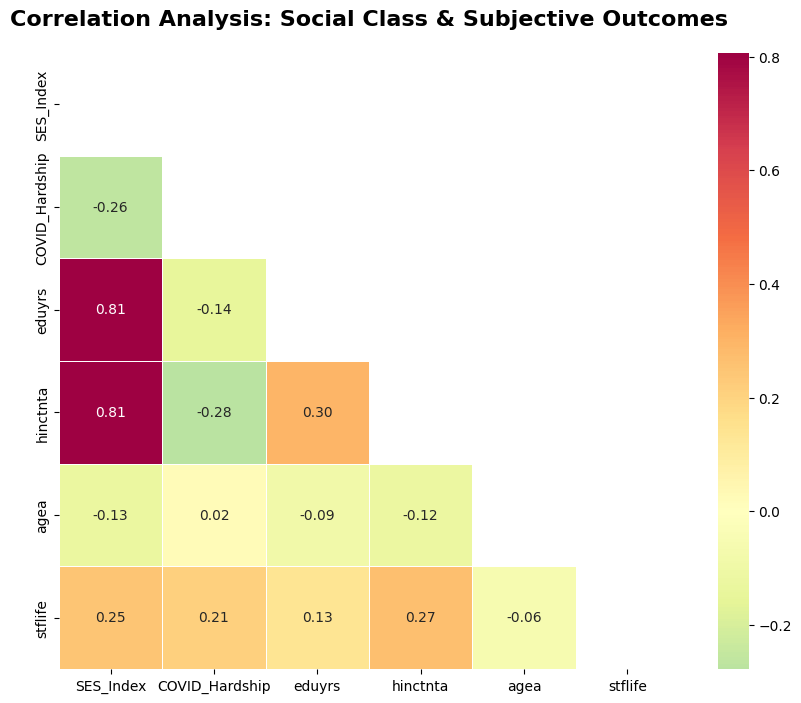

In [7]:
# Plot B: Correlation Matrix
plt.figure(figsize=(10, 8))
vars_to_corr = ['SES_Index', 'COVID_Hardship', 'eduyrs', 'hinctnta', 'agea', 'stflife']
corr_matrix = df[vars_to_corr].corr()
print("\n--- Correlation Matrix Results ---")
print(corr_matrix.round(3))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='Spectral_r', center=0, fmt=".2f", linewidths=0.5)
plt.title('Correlation Analysis: Social Class & Subjective Outcomes', fontsize=16, pad=20, weight='bold')
plt.savefig('Correlation_Heatmap.png')
plt.show()


# **Spatial Inequality: Country SES vs. COVID Hardship**

When plotting country-wide averages, the "Resilience Zone (bottom-right) is occupied by nations with high SES and low hardship, such as the **Netherlands (SES: ~0.35, Hardship: -0.13)**.
- **The Hotspots: Montenegro** is the most extreme outlier, with the highest hardship score in the study (**0.342**) coupled with a below-average SES (**-0.282**).
- **Ukraine** showed the lowest average SES (**-0.723**) and a high hardship score of **0.158**, highlighting the extreme vulnerability of that population.


--- Spatial Hotspot Results (Top 5 Highest Hardship Countries) ---
   country_name region  COVID_Hardship  SES_Index
17   Montenegro   East        0.342324  -0.281973
15       Latvia   East        0.221714  -0.074053
28      Ukraine   East        0.157931  -0.723107
16    Lithuania   East        0.117016   0.092102
10      Hungary   East        0.105126  -0.203427


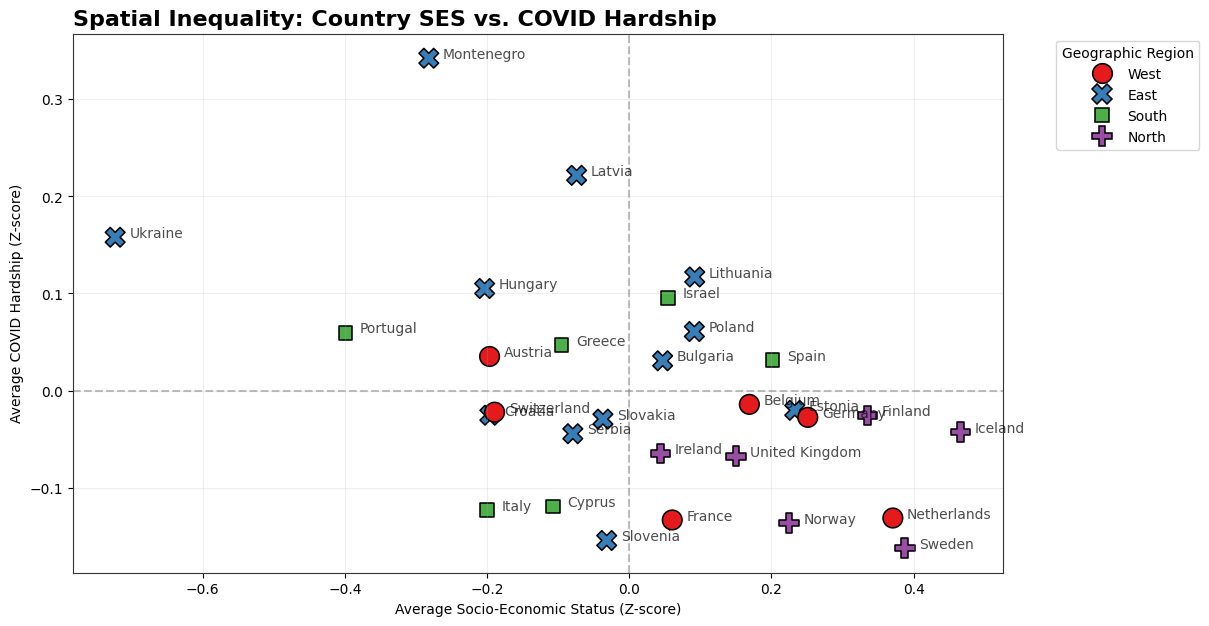

In [8]:
# Spatial Analysis (Hotspot Plot)
# Aggregate by Country for "Hotspot" detection
country_stats = df.groupby(['country_name', 'region']).agg({
    'COVID_Hardship': 'mean',
    'SES_Index': 'mean'
}).reset_index()

print("\n--- Spatial Hotspot Results (Top 5 Highest Hardship Countries) ---")
print(country_stats.sort_values(by='COVID_Hardship', ascending=False).head(5))

plt.figure(figsize=(12, 7))
sns.scatterplot(data=country_stats, x='SES_Index', y='COVID_Hardship',
                hue='region', style='region', s=200, palette='Set1', edgecolor='black')

for i in range(country_stats.shape[0]):
    plt.text(country_stats.SES_Index[i]+0.02, country_stats.COVID_Hardship[i],
             country_stats.country_name[i], fontsize=10, alpha=0.7)

plt.axhline(df['COVID_Hardship'].mean(), color='grey', linestyle='--', alpha=0.5)
plt.axvline(df['SES_Index'].mean(), color='grey', linestyle='--', alpha=0.5)

plt.title('Spatial Inequality: Country SES vs. COVID Hardship', loc='left', weight='bold', fontsize=16)
plt.xlabel('Average Socio-Economic Status (Z-score)')
plt.ylabel('Average COVID Hardship (Z-score)')
plt.legend(title='Geographic Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.savefig('Spatial_Hotspot.png')
plt.show()

# **Geographic Ranking: Average COVID Hardship by Country**

This ranking provides a clear look at national resilience. **Sweden (-0.162)** and **Slovenia (-0.154)** are the top performers, reporting the least distress. Conversely, the **"hardship heavyweights"** are concentrated in the East, led by **Montenegro (0.342)**, **Latvia (0.222)**, and **Ukraine (0.158)**.


--- National Hardship Rankings (Mean Scores) ---
country_name
Sweden           -0.162376
Slovenia         -0.154410
Norway           -0.136624
France           -0.133262
Netherlands      -0.131243
Italy            -0.123398
Cyprus           -0.119372
United Kingdom   -0.067717
Ireland          -0.064814
Serbia           -0.044453
Iceland          -0.042599
Slovakia         -0.029420
Germany          -0.027593
Finland          -0.025843
Croatia          -0.025384
Switzerland      -0.022238
Estonia          -0.020330
Belgium          -0.014203
Bulgaria          0.030669
Spain             0.031212
Austria           0.035112
Greece            0.046512
Portugal          0.059674
Poland            0.060817
Israel            0.095721
Hungary           0.105126
Lithuania         0.117016
Ukraine           0.157931
Latvia            0.221714
Montenegro        0.342324
Name: COVID_Hardship, dtype: float64


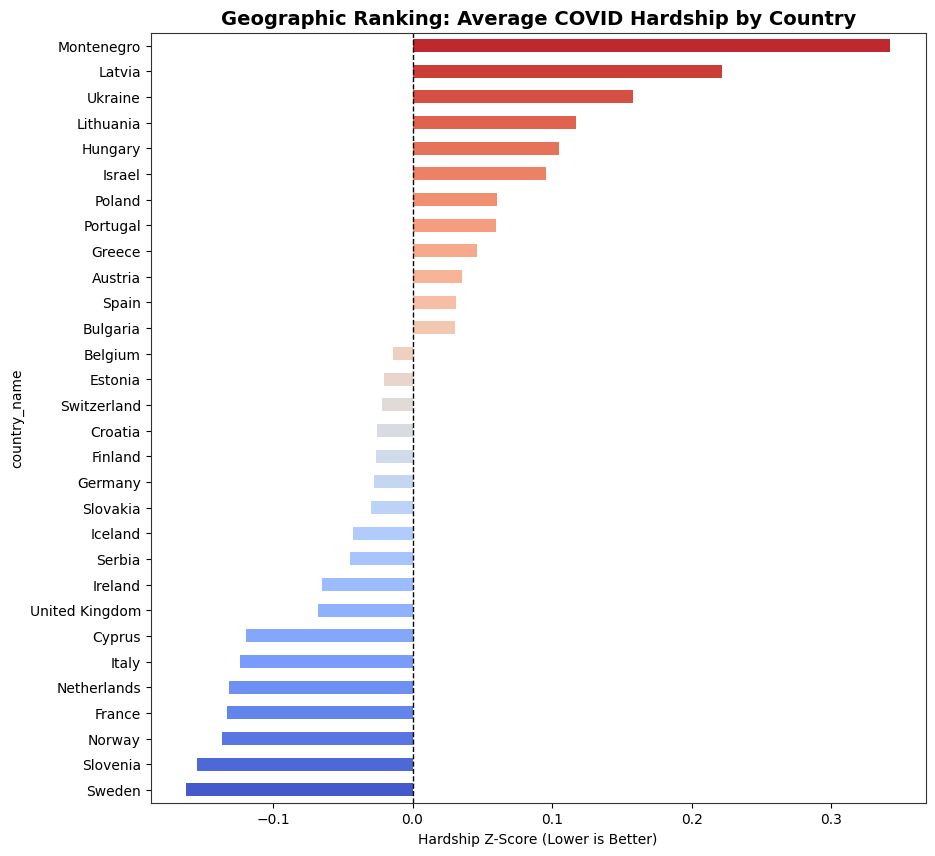

In [9]:
# Cross-National Ranking (Efficiency Plot)
print("\n--- National Hardship Rankings (Mean Scores) ---")
rank_data = df.groupby('country_name')['COVID_Hardship'].mean().sort_values()
print(rank_data)

plt.figure(figsize=(10, 10))
rank_data.plot(kind='barh', color=sns.color_palette("coolwarm", len(rank_data)))
plt.title('Geographic Ranking: Average COVID Hardship by Country', fontsize=14, weight='bold')
plt.axvline(0, color='black', lw=1, ls='--')
plt.xlabel('Hardship Z-Score (Lower is Better)')
plt.savefig('Spatial_Ranking.png')
plt.show()

# **The "Buffering" Effect (Grouped Bar Chart)**

This plot shows that being wealthy/educated helps regardless of where you live. In the **East**, the gap is massive: Low SES individuals hit a hardship peak of **0.218**, while High SES individuals in the same region stayed below the average at **-0.051**. In the **North**, High SES individuals reached the lowest hardship levels in the study at **-0.173**, showing the combined power of living in a wealthy region with high personal resources.


--- Regional SES Impact (Hardship by Region and Class) ---
SES_Group  Low SES  Middle SES  High SES
region                                  
East         0.218      -0.003    -0.051
North        0.069      -0.064    -0.173
South        0.113      -0.024    -0.152
West         0.100      -0.053    -0.157


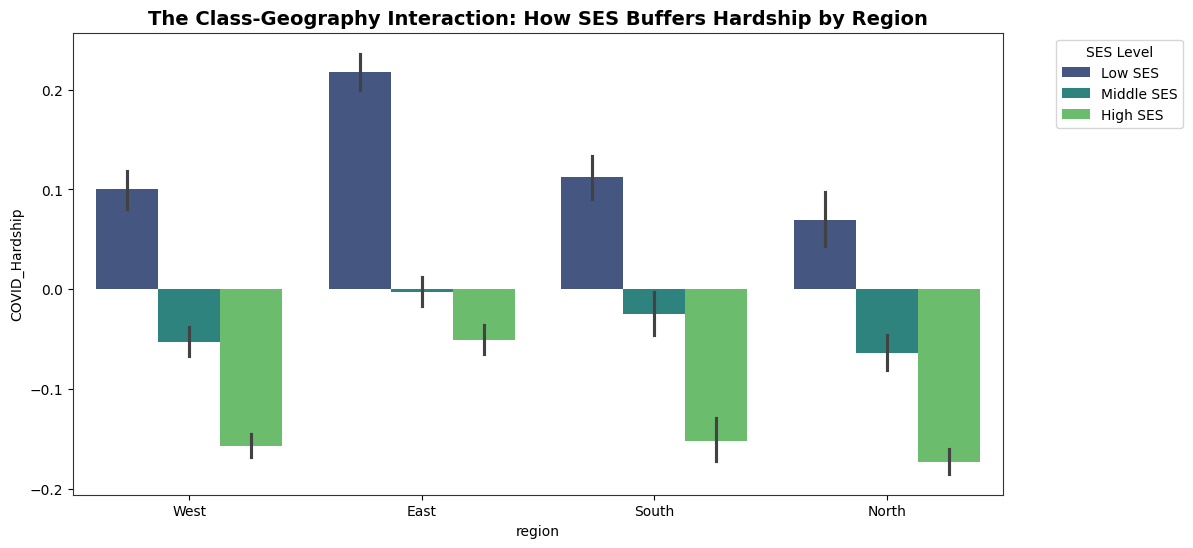

In [10]:
# Regional SES Interaction (The Vulnerability Gap)
print("\n--- Regional SES Impact (Hardship by Region and Class) ---")
interaction_results = df.groupby(['region', 'SES_Group'])['COVID_Hardship'].mean().unstack()
print(interaction_results.round(3))

plt.figure(figsize=(12, 6))
sns.barplot(x='region', y='COVID_Hardship', hue='SES_Group', data=df, palette='viridis')
plt.title('The Class-Geography Interaction: How SES Buffers Hardship by Region', fontsize=14, weight='bold')
plt.legend(title='SES Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('Spatial_SES_Interaction.png')
plt.show()


# **The Age Factor (Trend Lines)**

The **"Age Gradient"** varies by geography. In the **North (-0.063 correlation)** and **West (-0.032 correlation)**, hardship actually decreased as people got older, likely due to strong pension systems. However, in the **East**, the trend reversed with a **0.072 correlation**, meaning older citizens in Eastern Europe faced significantly more hardship than their younger counterparts.


---Regional Age-Hardship Correlations ---
Region: West | Correlation between Age and Hardship: -0.032
Region: East | Correlation between Age and Hardship: 0.072
Region: South | Correlation between Age and Hardship: 0.021
Region: North | Correlation between Age and Hardship: -0.063


<Figure size 1200x800 with 0 Axes>

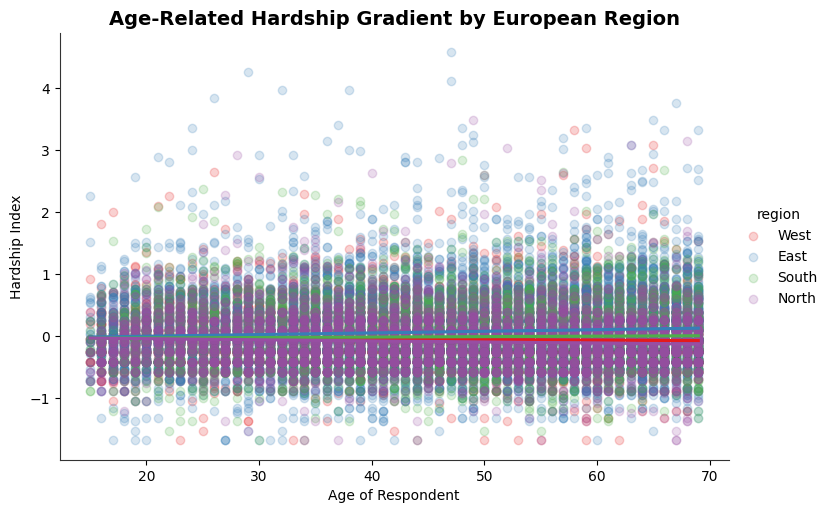


Analysis complete. All numerical results printed and  plots saved as PNG files.


In [11]:
# Geographic Gradient - Age vs. Hardship by Region
print("\n---Regional Age-Hardship Correlations ---")
for reg in df['region'].unique():
    subset = df[df['region'] == reg]
    correlation = subset['agea'].corr(subset['COVID_Hardship'])
    print(f"Region: {reg} | Correlation between Age and Hardship: {correlation:.3f}")

plt.figure(figsize=(12, 8))
sns.lmplot(x='agea', y='COVID_Hardship', hue='region', data=df,
           aspect=1.5, scatter_kws={'alpha':0.2}, palette='Set1')
plt.title('Age-Related Hardship Gradient by European Region', fontsize=14, weight='bold')
plt.xlabel('Age of Respondent')
plt.ylabel('Hardship Index')
plt.savefig('Spatial_Age_Gradient.png', dpi=300)
plt.show()

print("\nAnalysis complete. All numerical results printed and  plots saved as PNG files.")



# **Conclusion**

The data confirms a story of **"Spatial and Social Inequality."** The pandemic hit those with the fewest resources the hardest.
- The most resilient individuals were those in the **High SES group** living in the North (mean hardship **-0.173**).
- The most vulnerable were **Low SES individuals** in the **East** (mean hardship **0.218**).

The **"Wealth Shield"** (the -0.26 correlation) was universal; regardless of the country, having higher income and education significantly buffered people against the psychological and financial distress of the pandemic. Socio-economic status remains the single most important factor in determining how well a person survives a global crisis.